# ft_linear_regression
Trouver une formule qui permet de prédire le prix d'une voiture si on connaît son kilométrage.

In [4]:
# 1. IMPORTS

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
# 2. CHARGER LES DONNÉES

df = pd.read_csv("data.csv")
print(df.describe())

kms = df['km'].values
prices = df['price'].values

print(f"Nombre de voitures: {len(kms)}")
print(f"Kilométrage: de {min(kms)} à {max(kms)} km")
print(f"Prix: de {min(prices)} à {max(prices)} €")

                  km        price
count      24.000000    24.000000
mean   101066.250000  6331.833333
std     52674.245606  1319.654193
min     22899.000000  3650.000000
25%     65020.500000  5687.500000
50%     83014.500000  6495.000000
75%    140975.000000  7115.000000
max    240000.000000  8290.000000
Nombre de voitures: 24
Kilométrage: de 22899 à 240000 km
Prix: de 3650 à 8290 €


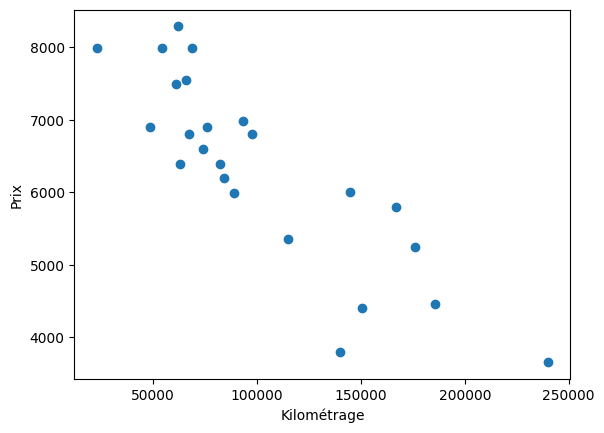

In [17]:
# 3. VISUALISER LES DONNÉES

plt.scatter(kms, prices)
plt.xlabel('Kilométrage')
plt.ylabel('Prix')
plt.show()

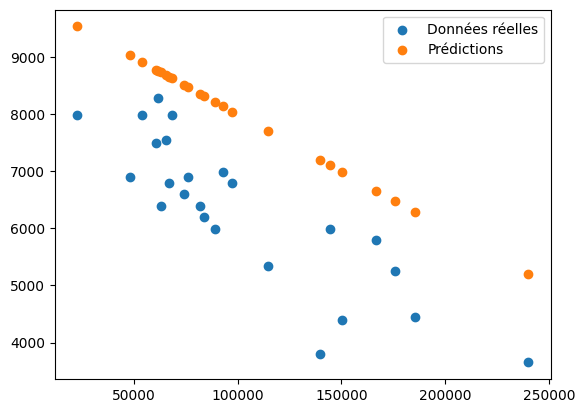

In [33]:
# 4. TESTER UNE DROITE MANUELLEMENT

theta0 = 10_000 	# On teste avec 
theta1 = -0.02		# des valeus au bol

predictions = theta0 + theta1 * kms

plt.scatter(kms, prices, label='Données réelles')
plt.scatter(kms, predictions, label='Prédictions')
plt.legend()
plt.show()

In [34]:
# 5. CALCULER L'ERREUR

def calculate_error(theta0: float, 
                    theta1: float, 
                    kms: list[float], 
                    prices: list[float]) -> float:
    """
    Calcule l'erreur moyenne entre les prédictions et les prix réels.
    """
    errors = []

    for km, price in zip(kms, prices):
        prediction = theta0 + theta1 * km
        error = abs(prediction - price)
        errors.append(error)

    return sum(errors) / len(errors)

error = calculate_error(theta0=theta0, theta1=theta1, kms=kms, prices=prices)
print(f"Erreur moyenne : {error:.2f}€")

Erreur moyenne : 1646.84€


Best match     : theta0[8420.95], theta1[-0.020000]
Erreur moyenne : 549.03€


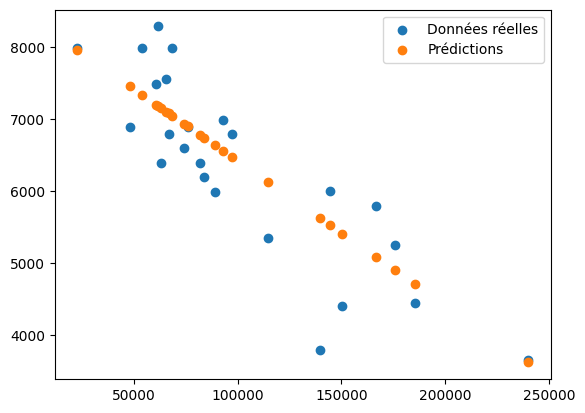

In [41]:
# 6. CHERCHER LES MEILLEURS θ

def iterate_gradient_descent(kms: list[float], 
                             prices: list[float], 
                             theta0: float, 
                             theta1: float, 
                             step: float,
                             iterations: int) -> tuple[float, float]:
    """
    Descente de gradient simple
    """
    for _ in range(iterations):
        error = calculate_error(theta0, theta1, kms, prices)
        
        # Teste les 4 directions
        error_up_0 = calculate_error(theta0 + step, theta1, kms, prices)
        error_down_0 = calculate_error(theta0 - step, theta1, kms, prices)
        error_up_1 = calculate_error(theta0, theta1 + step * 0.0001, kms, prices)
        error_down_1 = calculate_error(theta0, theta1 - step * 0.0001, kms, prices)
        
        # Bouge vers la meilleure direction
        best = min(error, error_up_0, error_down_0, error_up_1, error_down_1)
        
        if best == error_up_0:
            theta0 += step
        elif best == error_down_0:
            theta0 -= step
        elif best == error_up_1:
            theta1 += step * 0.0001
        elif best == error_down_1:
            theta1 -= step * 0.0001
        else:
            step *= 0.95
        
        if step < 0.01:
            break
    
    return theta0, theta1

# Check de l'implémentation    
theta0, theta1 = iterate_gradient_descent(kms=kms, prices=prices, theta0=theta0, theta1=theta1, step=100, iterations=1000)
print(f"Best match     : theta0[{theta0:.2f}], theta1[{theta1:.6f}]")

error = calculate_error(theta0=theta0, theta1=theta1, kms=kms, prices=prices)
print(f"Erreur moyenne : {error:.2f}€")

predictions = theta0 + theta1 * kms
plt.scatter(kms, prices, label='Données réelles')
plt.scatter(kms, predictions, label='Prédictions')
plt.legend()
plt.show()

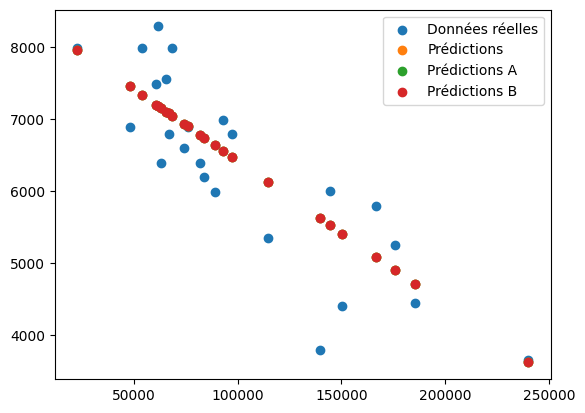

In [48]:
# Test aves d'autres valeurs de départ

theta0a, theta1a = iterate_gradient_descent(kms=kms, prices=prices, theta0=5000, theta1=-0.01, step=100, iterations=1000)
theta0b, theta1b = iterate_gradient_descent(kms=kms, prices=prices, theta0=15000, theta1=-0.05, step=100, iterations=1000)

predictions_a = theta0 + theta1 * kms
predictions_b = theta0 + theta1 * kms

plt.scatter(kms, prices, label='Données réelles')
plt.scatter(kms, predictions, label='Prédictions')
plt.scatter(kms, predictions_a, label='Prédictions A')
plt.scatter(kms, predictions_b, label='Prédictions B')
plt.legend()
plt.show()


In [49]:
# 7. BONUS PART

def calculate_r2(theta0: float, 
                 theta1: float, 
                 kms: list[float], 
                 prices: list[float]) -> float:
    """
    Calcule le coefficient de détermination R²
    R² = 1 - (SS_res / SS_tot)
    
    SS_res = somme des carrés des résidus (erreurs)
    SS_tot = variance totale des données
    """
    # Prédictions
    predictions = theta0 + theta1 * kms
    
    # Moyenne des prix réels
    mean_price = sum(prices) / len(prices)
    
    # SS_res : somme des carrés des résidus
    ss_res = sum((price - pred) ** 2 for price, pred in zip(prices, predictions))
    
    # SS_tot : variance totale
    ss_tot = sum((price - mean_price) ** 2 for price in prices)
    
    # R²
    r2 = 1 - (ss_res / ss_tot)
    
    return r2


# Utilisation
r2 = calculate_r2(theta0, theta1, kms, prices)
print(f"Précision du modèle (R²) : {r2:.4f}")
print(f"Le modèle explique {r2*100:.2f}% de la variance des données")

Précision du modèle (R²) : 0.7269
Le modèle explique 72.69% de la variance des données


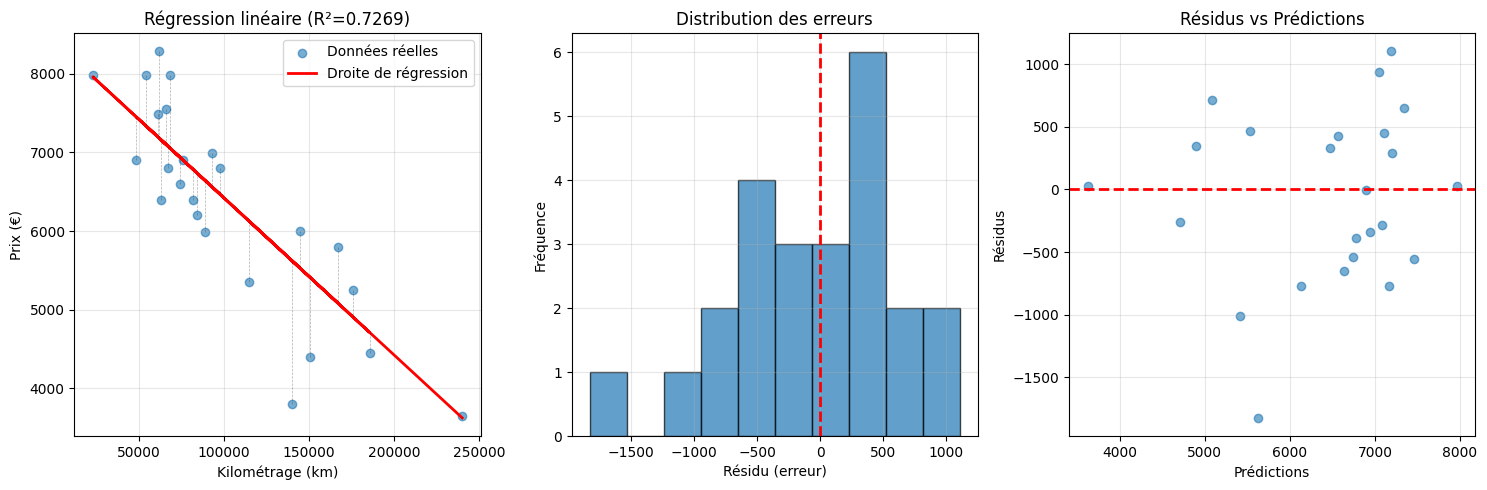

In [50]:
# 8. Visualistion

# 1. Graphique avec résidus (erreurs)
plt.figure(figsize=(15, 5))

# Subplot 1 : Données + droite + résidus
plt.subplot(1, 3, 1)
predictions = theta0 + theta1 * kms
plt.scatter(kms, prices, alpha=0.6, label='Données réelles')
plt.plot(kms, predictions, 'r-', linewidth=2, label='Droite de régression')

# Tracer les lignes d'erreur
for km, price, pred in zip(kms, prices, predictions):
    plt.plot([km, km], [price, pred], 'k--', alpha=0.3, linewidth=0.5)

plt.xlabel('Kilométrage (km)')
plt.ylabel('Prix (€)')
plt.title(f'Régression linéaire (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2 : Distribution des résidus
plt.subplot(1, 3, 2)
residuals = prices - predictions
plt.hist(residuals, bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Résidu (erreur)')
plt.ylabel('Fréquence')
plt.title('Distribution des erreurs')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)

# Subplot 3 : Résidus vs prédictions
plt.subplot(1, 3, 3)
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Prédictions')
plt.ylabel('Résidus')
plt.title('Résidus vs Prédictions')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# 9. Comparaison avec numpy

# Modèle naïf : prédire toujours la moyenne
mean_price = prices.mean()
naive_predictions = np.full_like(prices, mean_price)

# Erreur du modèle naïf
naive_error = np.mean(np.abs(prices - naive_predictions))
your_error = np.mean(np.abs(residuals))

print(f"\nCOMPARAISON :")
print(f"Erreur modèle naïf (moyenne) : {naive_error:.2f}€")
print(f"Erreur ton modèle            : {your_error:.2f}€")
print(f"Amélioration                 : {((naive_error - your_error) / naive_error * 100):.1f}%")

# Teste pour des valeurs extrêmes ?
test_cases = [0, 50000, 100000, 150000, 200000, 250000, 300000]
for km in test_cases:
    price = theta0 + theta1 * km
    print(f"{km:7d} km → {price:7.2f}€")


COMPARAISON :
Erreur modèle naïf (moyenne) : 1035.92€
Erreur ton modèle            : 549.03€
Amélioration                 : 47.0%
      0 km → 8420.95€
  50000 km → 7420.95€
 100000 km → 6420.95€
 150000 km → 5420.95€
 200000 km → 4420.95€
 250000 km → 3420.95€
 300000 km → 2420.95€
